In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import random

# Set seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)



In [10]:
test_folder = "Testing"

# Load test dataset
test_dataset = datasets.ImageFolder(root=test_folder, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]))
# Create DataLoaders
batch_size = 32

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

print(f"Test size: {len(test_dataset)}")




Test size: 394


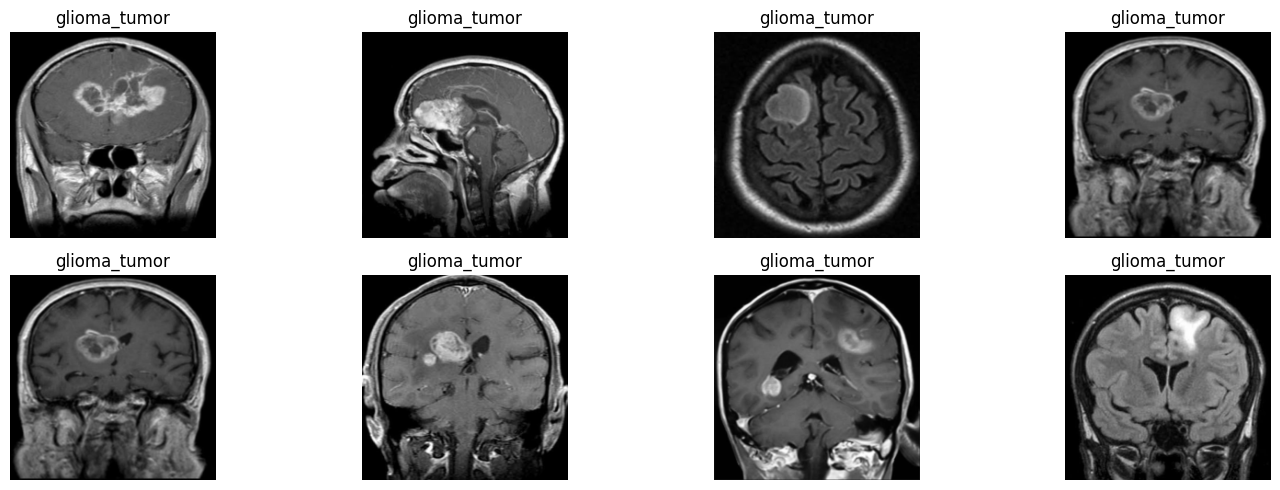

In [11]:
# Visualize some images
def show_images(dataset, n=8):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # From (C,H,W) to (H,W,C)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(dataset.classes[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show some training images
show_images(test_dataset)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
from transformers import ViTForImageClassification
from torchvision.models import swin_v2_b, Swin_V2_B_Weights, convnext_base, ConvNeXt_Base_Weights

def create_vit():
    model = ViTForImageClassification.from_pretrained(
        "google/vit-base-patch16-224-in21k",
        num_labels=4
    )
    # Freeze everything (optional, just to be explicit)
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze attention blocks (encoder layers)
    for layer in model.vit.encoder.layer:
        for param in layer.parameters():
            param.requires_grad = True

    # Always train classification head
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def create_resnet18():
    model = models.resnet18(pretrained=True)# Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layer4 and fc
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, 4)
    return model


def create_mobilenetv2():
    model = models.mobilenet_v2(pretrained=True)# Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze BatchNorm layers
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            for param in m.parameters():
                param.requires_grad = True

    # Replace and unfreeze classifier
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 4)

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def create_densenet121():
    model = models.densenet121(pretrained=True)# Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze BatchNorm layers
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            for param in m.parameters():
                param.requires_grad = True

    # Replace and unfreeze classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, 4)

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def create_convnext():
    weights = ConvNeXt_Base_Weights.DEFAULT
    model = convnext_base(weights=weights)
    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.features[12:].parameters():
        param.requires_grad = True

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 4)

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

def create_swin_transformer():
    weights = Swin_V2_B_Weights.DEFAULT
    model = swin_v2_b(weights=weights)    
    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze only qkv and proj in attention modules
    for name, module in model.named_modules():
        if hasattr(module, "qkv"):
            for param in module.qkv.parameters():
                param.requires_grad = True
        if hasattr(module, "proj"):
            for param in module.proj.parameters():
                param.requires_grad = True

    model.head = nn.Linear(model.head.in_features, 4)

    for param in model.head.parameters():
        param.requires_grad = True

    return model

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/cvteam2/anaconda3/envs/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cvteam2/anaconda3/envs/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/cvteam2/an

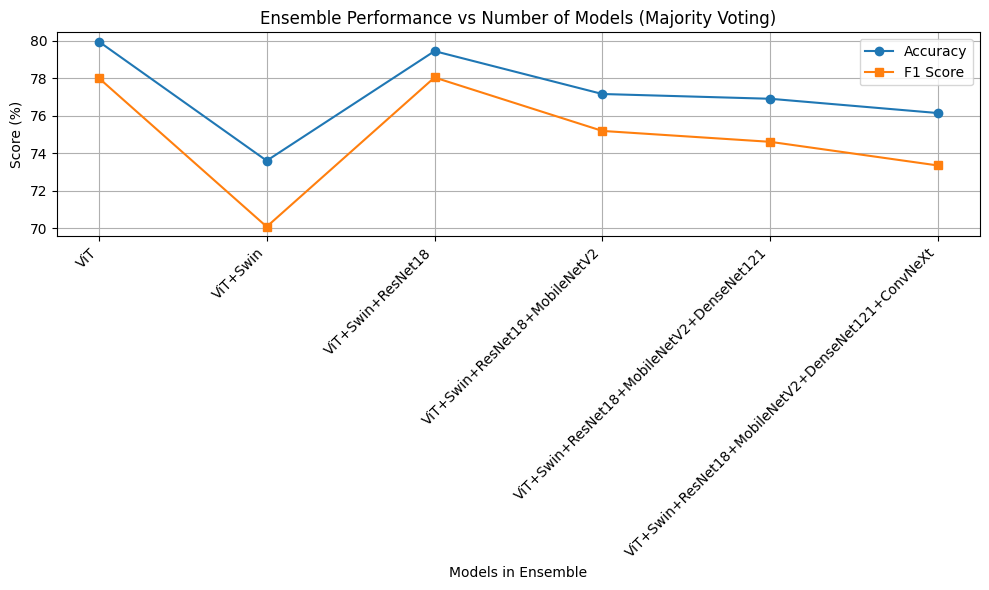

In [14]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

vit = create_vit()
vit.load_state_dict(torch.load("ViT_best.pth"))

mobilenetv2 = create_mobilenetv2()
mobilenetv2.load_state_dict(torch.load("MobileNetV2_best.pth"))

resnet18 = create_resnet18()
resnet18.load_state_dict(torch.load("ResNet18_best.pth"))

swin = create_swin_transformer()
swin.load_state_dict(torch.load("swin_best.pth"))

densenet = create_densenet121()
densenet.load_state_dict(torch.load("DenseNet121_best.pth"))

convnext = create_convnext()
convnext.load_state_dict(torch.load("ConvNeXt_best.pth"))

# Define models and their weights based on validation/test scores
models_ranked = [
    ("ViT", vit, 0.40),
    ("Swin", swin, 0.30),
    ("ResNet18", resnet18, 0.15),
    ("MobileNetV2", mobilenetv2, 0.10),
    ("DenseNet121", densenet, 0.04),
    ("ConvNeXt", convnext, 0.01),
]

def evaluate_ensemble_majority_voting(models_with_weights, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    y_true = []
    y_pred = []

    for model_name, model, _ in models_with_weights:
        model.eval()
        model.to(device)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # Collect predictions from all models
            all_preds = []

            for _, model, _ in models_with_weights:
                output = model(images)
                logits = output.logits if hasattr(output, 'logits') else output
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds)

            # Majority voting
            all_preds = torch.stack(all_preds, dim=0)  # Shape: [num_models, batch_size]
            majority_preds = torch.mode(all_preds, dim=0)[0]  # Take majority vote across models

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(majority_preds.cpu().numpy())
    
    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average='macro') * 100
    return acc, f1

# This will store scores
ensemble_accs = []
ensemble_f1s = []
ensemble_names = []

# Simulate incremental ensemble
for i in range(1, len(models_ranked) + 1):
    subset = models_ranked[:i]
    names = '+'.join([name for name, _, _ in subset])
    ensemble_names.append(names)
    
    # Replace this with actual models in subset
    active_models = [entry for entry in subset if entry[1] is not None]

    # Skip if dummy models are still None
    if not active_models:
        continue

    acc, f1 = evaluate_ensemble_majority_voting(active_models, test_loader)  
    ensemble_accs.append(acc)
    ensemble_f1s.append(f1)

# Plotting the result
plt.figure(figsize=(10, 6))
plt.plot(ensemble_names, ensemble_accs, marker='o', label="Accuracy")
plt.plot(ensemble_names, ensemble_f1s, marker='s', label="F1 Score")
plt.title("Ensemble Performance vs Number of Models (Majority Voting)")
plt.xlabel("Models in Ensemble")
plt.ylabel("Score (%)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('ensemble_majority_voting.png')
plt.show()
